# PACER Demo: Synthetic Data

This notebook demonstrates how to run PACER on synthetic interventional data and visualise the inferred causal graph against the ground truth.

**Outline**
1. Generate a random DAG and interventional data
2. Format data for PACER (`x`, `masks`, `regimes`)
3. Fit PACER
4. Evaluate (SHD, precision, recall)
5. Visualise inferred vs ground-truth network

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd

from pacer import PACER

np.random.seed(42)

## 2. Generate Synthetic Data


### DAG generation (follows DCDI's Erdős–Rényi approach)

DCDI samples a random *causal ordering* (permutation of node indices), then for each node draws parents from nodes that come *later* in that ordering with probability:

$p = 2 * \text{expected edges} / (n*(n-1))$

In [2]:
def random_dag(n_nodes, expected_degree=3, seed=0):
    """
    Sample a random DAG using DCDI's Erdős–Rényi scheme.

    A random causal ordering (permutation) is drawn first.
    For each node in the ordering, parents are sampled from nodes
    that come *later* in that ordering (i.e. are causally upstream).

    adj[i, j] = 1  means  i → j  (i is a parent of j).

    Parameters
    ----------
    n_nodes: int
        number of nodes in DAG
    expected_degree: int, optional (default=3)
        expected edges per node
    seed : int, optional (default=0)
        Random seed for reproducibility.

    Returns
    -------
    adj : np.ndarray of shape (n_nodes, n_nodes)
        Adjacency matrix of the DAG, where adj[i, j] = 1 means i → j.

    """
    rng = np.random.RandomState(seed)
    n = n_nodes
    nb_edges   = expected_degree * n
    prob_conn  = 2 * nb_edges / (n**2 - n)   # same formula as DCDI

    adj = np.zeros((n, n), dtype=int)
    causal_order = rng.permutation(n)          # random topological order

    for i in range(n - 1):
        node            = causal_order[i]
        possible_parents= causal_order[i + 1:]     # nodes upstream in the order
        num_parents     = rng.binomial(n - i - 1, prob_conn)
        parents         = rng.choice(possible_parents, size=num_parents, replace=False)
        adj[parents, node] = 1                  # parents → node

    return adj


### Data simulation (linear Gaussian SCM)

Follows DCDI's LinearMechanism:

$X_j = Σ_i  w_{ij} · X_i  +  \text{noise coeff} · ε_j,   ε_j ~ N(0,1)$

Edge weights are sampled uniformly in [-1, -0.5] ∪ [0.5, 1].

Interventions are *structural*: the intervened variable is re-sampled from N(0,1) independently of its parents (hard do-intervention).

Output arrays mirror the DCDI file format:
- x       (N, d)  – all samples concatenated (obs + interventional)
- masks   (N, d)  – 1 = not intervened, 0 = intervened on
- regimes (N,)    – 0 = observational, k = k-th interventional regime

In [3]:
def simulate_linear_gaussian(dag, n_obs=500, n_interv_per_node=100,
                              noise_coeff=0.4, seed=0):
    """
    Simulate interventional data from a linear Gaussian structural causal model.

    Parameters
    ----------
    dag : np.ndarray of shape (d, d)
        Binary adjacency matrix of the ground-truth DAG.
        dag[i, j] = 1 means i → j (i is a parent of j).
    n_obs : int, optional (default=500)
        Number of samples drawn from the observational regime (no intervention).
    n_interv_per_node : int, optional (default=100)
        Number of samples per interventional regime. One regime is created for
        each node, so the full dataset has n_obs + d * n_interv_per_node rows.
    noise_coeff : float, optional (default=0.4)
        Standard deviation of the additive Gaussian noise on each variable.
        Matches DCDI's noise_coeff parameter in LinearMechanism.
    seed : int, optional (default=0)
        Random seed for reproducibility.

    Returns
    -------
    x : np.ndarray of shape (N, d)
        Concatenated expression matrix (observational + interventional samples).
    masks : np.ndarray of shape (N, d)
        Binary intervention mask. Entry [i, j] is 1 if variable j was *not*
        intervened on in sample i, and 0 if it was the intervention target.
    regimes : np.ndarray of shape (N,) of dtype int
        Regime index for each sample. 0 = observational;
        k ∈ {1, …, d} = hard intervention on node (k-1).
    """
    
    rng = np.random.RandomState(seed)
    d   = dag.shape[0]

    # Edge weights: uniform magnitude in [0.5, 1], random sign
    W = dag.astype(float) * (
        rng.uniform(0.5, 1.0, (d, d)) * rng.choice([-1, 1], size=(d, d))
    )

    # Topological order from the DAG
    import networkx as nx
    topo_order = list(nx.topological_sort(nx.DiGraph(dag)))

    def _sample(n, intervened_node=None):
        X = np.zeros((n, d))
        for node in topo_order:
            if intervened_node == node:
                X[:, node] = rng.randn(n)          # hard intervention
            else:
                parents = np.where(dag[:, node])[0]
                X[:, node] = (X[:, parents] @ W[parents, node]
                              + noise_coeff * rng.randn(n))
        return X

    # Observational regime (regime 0)
    X_list = [_sample(n_obs)]
    M_list = [np.ones((n_obs, d))]
    R_list = [np.zeros(n_obs, dtype=int)]

    # One hard-intervention regime per node (regimes 1 … d)
    for k, node in enumerate(range(d)):
        X_k = _sample(n_interv_per_node, intervened_node=node)
        M_k = np.ones((n_interv_per_node, d))
        M_k[:, node] = 0.0
        R_k = np.full(n_interv_per_node, k + 1, dtype=int)
        X_list.append(X_k); M_list.append(M_k); R_list.append(R_k)

    x       = np.vstack(X_list)
    masks   = np.vstack(M_list)
    regimes = np.concatenate(R_list)
    return x, masks, regimes



### Generate DAG

In [4]:
N_NODES        = 10
EXPECTED_DEGREE = 2

gt_dag = random_dag(n_nodes=N_NODES, expected_degree=EXPECTED_DEGREE, seed=0)
node_names = [f'X{i}' for i in range(N_NODES)]

x, masks, regimes = simulate_linear_gaussian(
    gt_dag, n_obs=2000, n_interv_per_node=200, noise_coeff=0.5, seed=0
)

print(f'Ground-truth DAG  — nodes: {N_NODES}, edges: {int(gt_dag.sum())}')
print(f'Dataset shape     — x: {x.shape}, masks: {masks.shape}, regimes: {regimes.shape}')


Ground-truth DAG  — nodes: 10, edges: 21
Dataset shape     — x: (4000, 10), masks: (4000, 10), regimes: (4000,)


## 3. Fit PACER

In [5]:
# Train / validation split
rng = np.random.RandomState(0)
idx = rng.permutation(len(x))
split = int(0.8 * len(x))
train_idx, val_idx = idx[:split], idx[split:]

x_train, masks_train, regimes_train = x[train_idx], masks[train_idx], regimes[train_idx]
x_val,   masks_val,   regimes_val   = x[val_idx],   masks[val_idx],   regimes[val_idx]

print(f'Train: {x_train.shape[0]} samples | Val: {x_val.shape[0]} samples')

Train: 3200 samples | Val: 800 samples


In [6]:
pacer = PACER(
    n_vars      = N_NODES,
    n_steps     = 5000,
    lr          = 1e-2,
    batch_size  = 64,
    n_mc_samples= 200,
    lambd       = 1.0,
    seed        = 0,
    fit_analytic = True  # Set to False to switch to REINFORCE
)

out = pacer.fit(
    x_train      = x_train,
    masks_train  = masks_train,
    regimes_train= regimes_train,
    x_val        = x_val,
    masks_val    = masks_val,
    regimes_val  = regimes_val,
)
print('Training complete.')

Step 199: Train 11.291 |  Validation 0.916   Max: 1.024
Step 399: Train 9.386 |  Validation 0.825   Max: 0.904
Step 599: Train 8.531 |  Validation 0.773   Max: 0.858
Step 799: Train 8.094 |  Validation 0.752   Max: 0.844
Step 999: Train 7.886 |  Validation 0.751   Max: 0.842
Step 1199: Train 7.830 |  Validation 0.746   Max: 0.842
Step 1399: Train 7.763 |  Validation 0.741   Max: 0.835
Step 1599: Train 7.741 |  Validation 0.738   Max: 0.831
Step 1799: Train 7.677 |  Validation 0.738   Max: 0.831
Step 1999: Train 7.663 |  Validation 0.739   Max: 0.839
Step 2199: Train 7.670 |  Validation 0.737   Max: 0.831
Step 2399: Train 7.652 |  Validation 0.739   Max: 0.839
Step 2599: Train 7.645 |  Validation 0.738   Max: 0.840
Step 2799: Train 7.618 |  Validation 0.739   Max: 0.839
Step 2999: Train 7.626 |  Validation 0.736   Max: 0.826
Step 3199: Train 7.635 |  Validation 0.740   Max: 0.842
Step 3399: Train 7.601 |  Validation 0.738   Max: 0.832
Step 3599: Train 7.618 |  Validation 0.737   Max: 0.

## 4. Evaluate

In [7]:
edge_probs = pacer.predict_proba()          
pred_dag   = pacer.predict(threshold=0.5).astype(int)   

gt   = gt_dag.astype(bool)
pred = pred_dag.astype(bool)
diag = np.eye(N_NODES, dtype=bool)

tp  = int((gt  &  pred & ~diag).sum())
fp  = int((~gt &  pred & ~diag).sum())
fn  = int((gt  & ~pred & ~diag).sum())
rev = int((gt  &  pred.T & ~diag).sum())   

shd       = fp + fn + rev
precision = tp / max(tp + fp, 1)
recall    = tp / max(tp + fn, 1)
f1        = 2 * precision * recall / max(precision + recall, 1e-9)

# Results table 
results = pd.DataFrame({
    'Metric': [
        'GT edges', 'Predicted edges',
        'True Positives (TP)', 'False Positives (FP)',
        'False Negatives (FN)', 'Reversed (Rev)',
        'SHD', 'Precision', 'Recall', 'F1',
    ],
    'Value': [
        int(gt_dag.sum()), int(pred_dag.sum()),
        tp, fp, fn, rev,
        shd,
        f'{precision:.3f}', f'{recall:.3f}', f'{f1:.3f}',
    ],
}).set_index('Metric')

results


,Value
Metric,
GT edges,21
Predicted edges,22
True Positives (TP),19
False Positives (FP),3
False Negatives (FN),2
Reversed (Rev),2
SHD,7
Precision,0.864
Recall,0.905


## 5. Visualise Inferred vs Ground-Truth Network

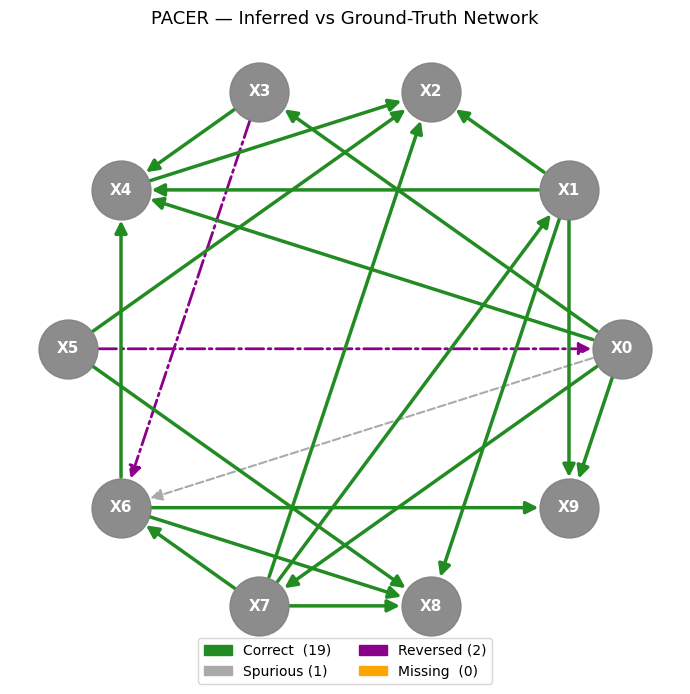

In [8]:
def classify_edges(gt, pred):
    """Return four edge lists: correct, reversed, spurious, missing."""
    n = gt.shape[0]
    correct, reversed_, spurious, missing = [], [], [], []
    counted_rev = set()
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            gt_ij   = bool(gt[i, j])
            pred_ij = bool(pred[i, j])
            gt_ji   = bool(gt[j, i])
            pred_ji = bool(pred[j, i])

            if gt_ij and pred_ij:
                correct.append((i, j))
            elif gt_ij and pred_ji and (j, i) not in counted_rev:
                reversed_.append((i, j))  # draw from GT direction
                counted_rev.add((i, j))
            elif pred_ij and not gt_ij and not gt_ji:
                spurious.append((i, j))
            elif gt_ij and not pred_ij and not pred_ji:
                missing.append((i, j))
    return correct, reversed_, spurious, missing


def plot_network_comparison(
    gt_dag, pred_dag, node_names=None, title='', ax=None
):
    """
    Circular graph showing Correct / Reversed / Spurious / Missing edges.
    """
    n = gt_dag.shape[0]
    if node_names is None:
        node_names = [str(i) for i in range(n)]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    pos = nx.circular_layout(G, scale=1.6)

    # Nodes
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color='#808080', node_size=1800, alpha=0.9
    )
    nx.draw_networkx_labels(
        G, pos, labels={i: node_names[i] for i in range(n)},
        ax=ax, font_color='white', font_size=11, font_weight='bold'
    )

    # Edge categories
    correct, reversed_, spurious, missing = classify_edges(gt_dag, pred_dag)

    edge_styles = [
        (missing,   '#FFA500', 'dashed',  1.5, 'Missing'),
        (spurious,  '#AAAAAA', 'dashed',  1.5, 'Spurious'),
        (reversed_, '#8B008B', 'dashdot', 2.0, 'Reversed'),
        (correct,   '#228B22', 'solid',   2.5, 'Correct'),
    ]

    for edges, color, style, lw, _ in edge_styles:
        if not edges:
            continue
        nx.draw_networkx_edges(
            G, pos, edgelist=edges, ax=ax,
            edge_color=color,
            style=style,
            width=lw,
            arrows=True,
            arrowsize=18,
            arrowstyle='-|>',
            connectionstyle='arc3,rad=0.0',
            min_source_margin=22,
            min_target_margin=22,
        )

    # Legend
    legend_handles = [
        mpatches.Patch(color='#228B22', label=f'Correct  ({len(correct)})'),
        mpatches.Patch(color='#AAAAAA', label=f'Spurious ({len(spurious)})'),
        mpatches.Patch(color='#8B008B', label=f'Reversed ({len(reversed_)})'),
        mpatches.Patch(color='#FFA500', label=f'Missing  ({len(missing)})'),
    ]
    ax.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=2,
        frameon=True,
        fontsize=10,
        bbox_to_anchor=(0.5, -0.05),
    )
    ax.set_title(title, fontsize=13, pad=10)
    ax.axis('off')


fig, ax = plt.subplots(figsize=(7, 7))
plot_network_comparison(
    gt_dag, pred_dag,
    node_names=node_names,
    title='PACER — Inferred vs Ground-Truth Network',
    ax=ax,
)
plt.tight_layout()
plt.show()

## 6. Edge Probability Heatmap

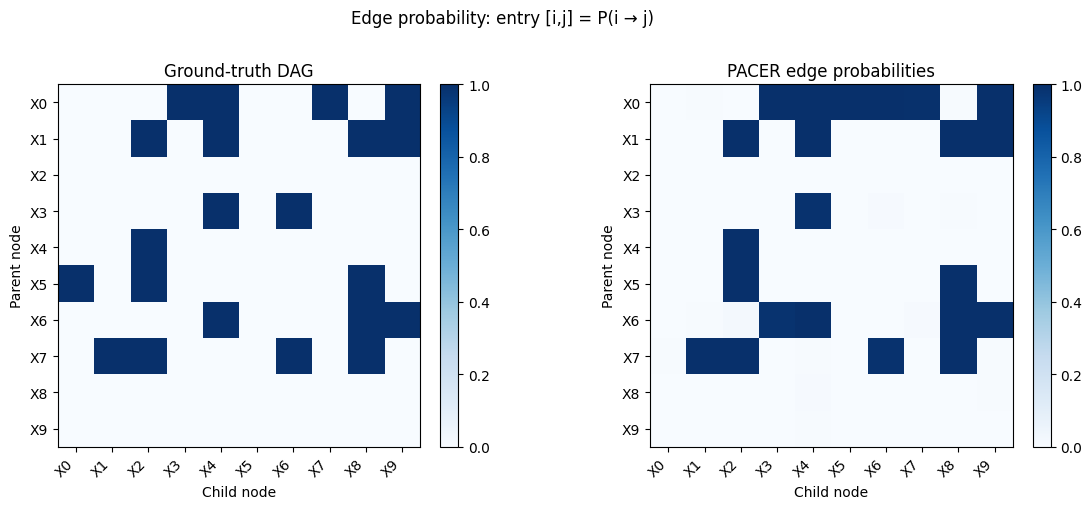

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title in zip(
    axes,
    [gt_dag.astype(float), edge_probs],
    ['Ground-truth DAG', 'PACER edge probabilities']
):
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(N_NODES)); ax.set_yticks(range(N_NODES))
    ax.set_xticklabels(node_names, rotation=45, ha='right')
    ax.set_yticklabels(node_names)
    ax.set_xlabel('Child node')
    ax.set_ylabel('Parent node')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Edge probability: entry [i,j] = P(i → j)', y=1.01)
plt.tight_layout()
plt.show()